Begin by importing the necessary libraries we use in the workflow and the custom functions we have built for each sub-wrokflow.

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use fixed absolute path to src/ directory
src_dir = "/Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/src"
os.chdir(src_dir)
print(f"Working directory set to: {os.getcwd()}")

# Only change if not already in src/
if not os.getcwd().endswith('/src'):
    os.chdir(src_dir)
    print(f"Working directory set to: {os.getcwd()}")

# Add src/ to path so we can import modules
if src_dir not in sys.path:
    sys.path.append(src_dir)

# Import custom data loader function
from modules.data_loader import create_subset_manifest

Working directory set to: /Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/src


Filter the existing train_labels.csv down to the subset of patient samples we will be using for training and testing.

In [2]:

import random

# Define your local paths (relative to src/ directory)
TRAIN_LABELS_CSV_PATH = "scripts/download_data/training_data_labels/train_labels.csv"
LOCAL_DATA_DIR = "sampled_train_fixed"
OUTPUT_JSON_DIR = "sampled_train_fixed/subset_manifest"
OUTPUT_JSON_PATH = os.path.join(OUTPUT_JSON_DIR, "subset_manifest.json")

if not os.path.exists(OUTPUT_JSON_DIR):
    os.makedirs(OUTPUT_JSON_DIR)

print(f"Current working directory: {os.getcwd()}")
print(f"CSV exists: {os.path.exists(TRAIN_LABELS_CSV_PATH)}")
print(f"Data dir exists: {os.path.exists(LOCAL_DATA_DIR)}")
print(f"Output JSON Directory: {os.path.exists(OUTPUT_JSON_DIR)}")

# Create the json subset manifest
create_subset_manifest(TRAIN_LABELS_CSV_PATH, LOCAL_DATA_DIR, OUTPUT_JSON_PATH)

# Load the newly created JSON to verify it worked
with open(OUTPUT_JSON_PATH, 'r') as f:
    local_manifest = json.load(f)

# Display the results of the subset manifest creation
print(f"Successfully mapped {len(local_manifest)} local patients.")
if len(local_manifest) > 0:
    print("\nSample mapping for the first patient:")
    print(json.dumps(local_manifest[0], indent=4))

# Split the 4 patients into train (3) and validation (1)
random.seed(42)
random.shuffle(local_manifest)
split_idx = int(0.8 * len(local_manifest))  
train_records = local_manifest[:split_idx]   
val_records = local_manifest[split_idx:]     
print(f"Train: {len(train_records)} patients")
print(f"Val: {len(val_records)} patients")

Current working directory: /Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/src
CSV exists: True
Data dir exists: True
Output JSON Directory: True
Found 4 patient directories
  train_1: selected train_1_a_1.nii
  train_10: selected train_10_a_2.nii
  train_10024: selected train_10024_a_2.nii
  train_10073: selected train_10073_b_2.nii

Total best volumes collected: 4
Best volume keys: ['train_1_a_1.nii', 'train_10_a_2.nii', 'train_10024_a_2.nii', 'train_10073_b_2.nii']
Created manifest with 4 patients at sampled_train_fixed/subset_manifest/subset_manifest.json
Successfully mapped 4 local patients.

Sample mapping for the first patient:
{
    "image": "sampled_train_fixed/train_1/train_1_a/train_1_a_1.nii",
    "label": [
        0.0,
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
        0.0,
        1.0,
        0.0,
        0.0,
        0.0,
        1.0,
        1.0,
        0.0,
        0.0


## Testing Preprocessing and Augmentation Pipeline

Demonstrating the complete transform pipeline for CT-RATE challenge:

### Preprocessing (CTRateTransform)
Creates a 3-channel 3D tensor using multi-window strategy:
- **Channel 0: Fluid/Soft Tissue Lens** - Pleural and pericardial effusion detection
- **Channel 1: Calcification/Bone Lens** - Coronary and arterial calcifications
- **Channel 2: Generalist Lens** - Adaptive percentile-based scaling for broad tissue contrast

### Training vs Validation Pipelines
- **Training:** Preprocessing + Augmentation (spatial, noise/blur, intensity)
- **Validation:** Preprocessing only (consistent evaluation)

This cell visualizes:
1. The 3-channel windowing strategy (validation/baseline)
2. The effect of augmentation on training data (comparison)

Creating Transform Pipelines

Training transforms: Preprocessing + Augmentation
Validation transforms: Preprocessing only (no augmentation)

Processing patient: sampled_train_fixed/train_10024/train_10024_a/train_10024_a_2.nii

Applying validation transforms (preprocessing only)...


/Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/venv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


Applying training transforms (preprocessing + augmentation)...
Transform Output Shapes
Validation output: torch.Size([3, 96, 224, 224]) [channels, depth, height, width]
Training output:   torch.Size([3, 96, 224, 224]) [channels, depth, height, width]

Visualization slices: 30, 48, 55 (out of 96 total slices)


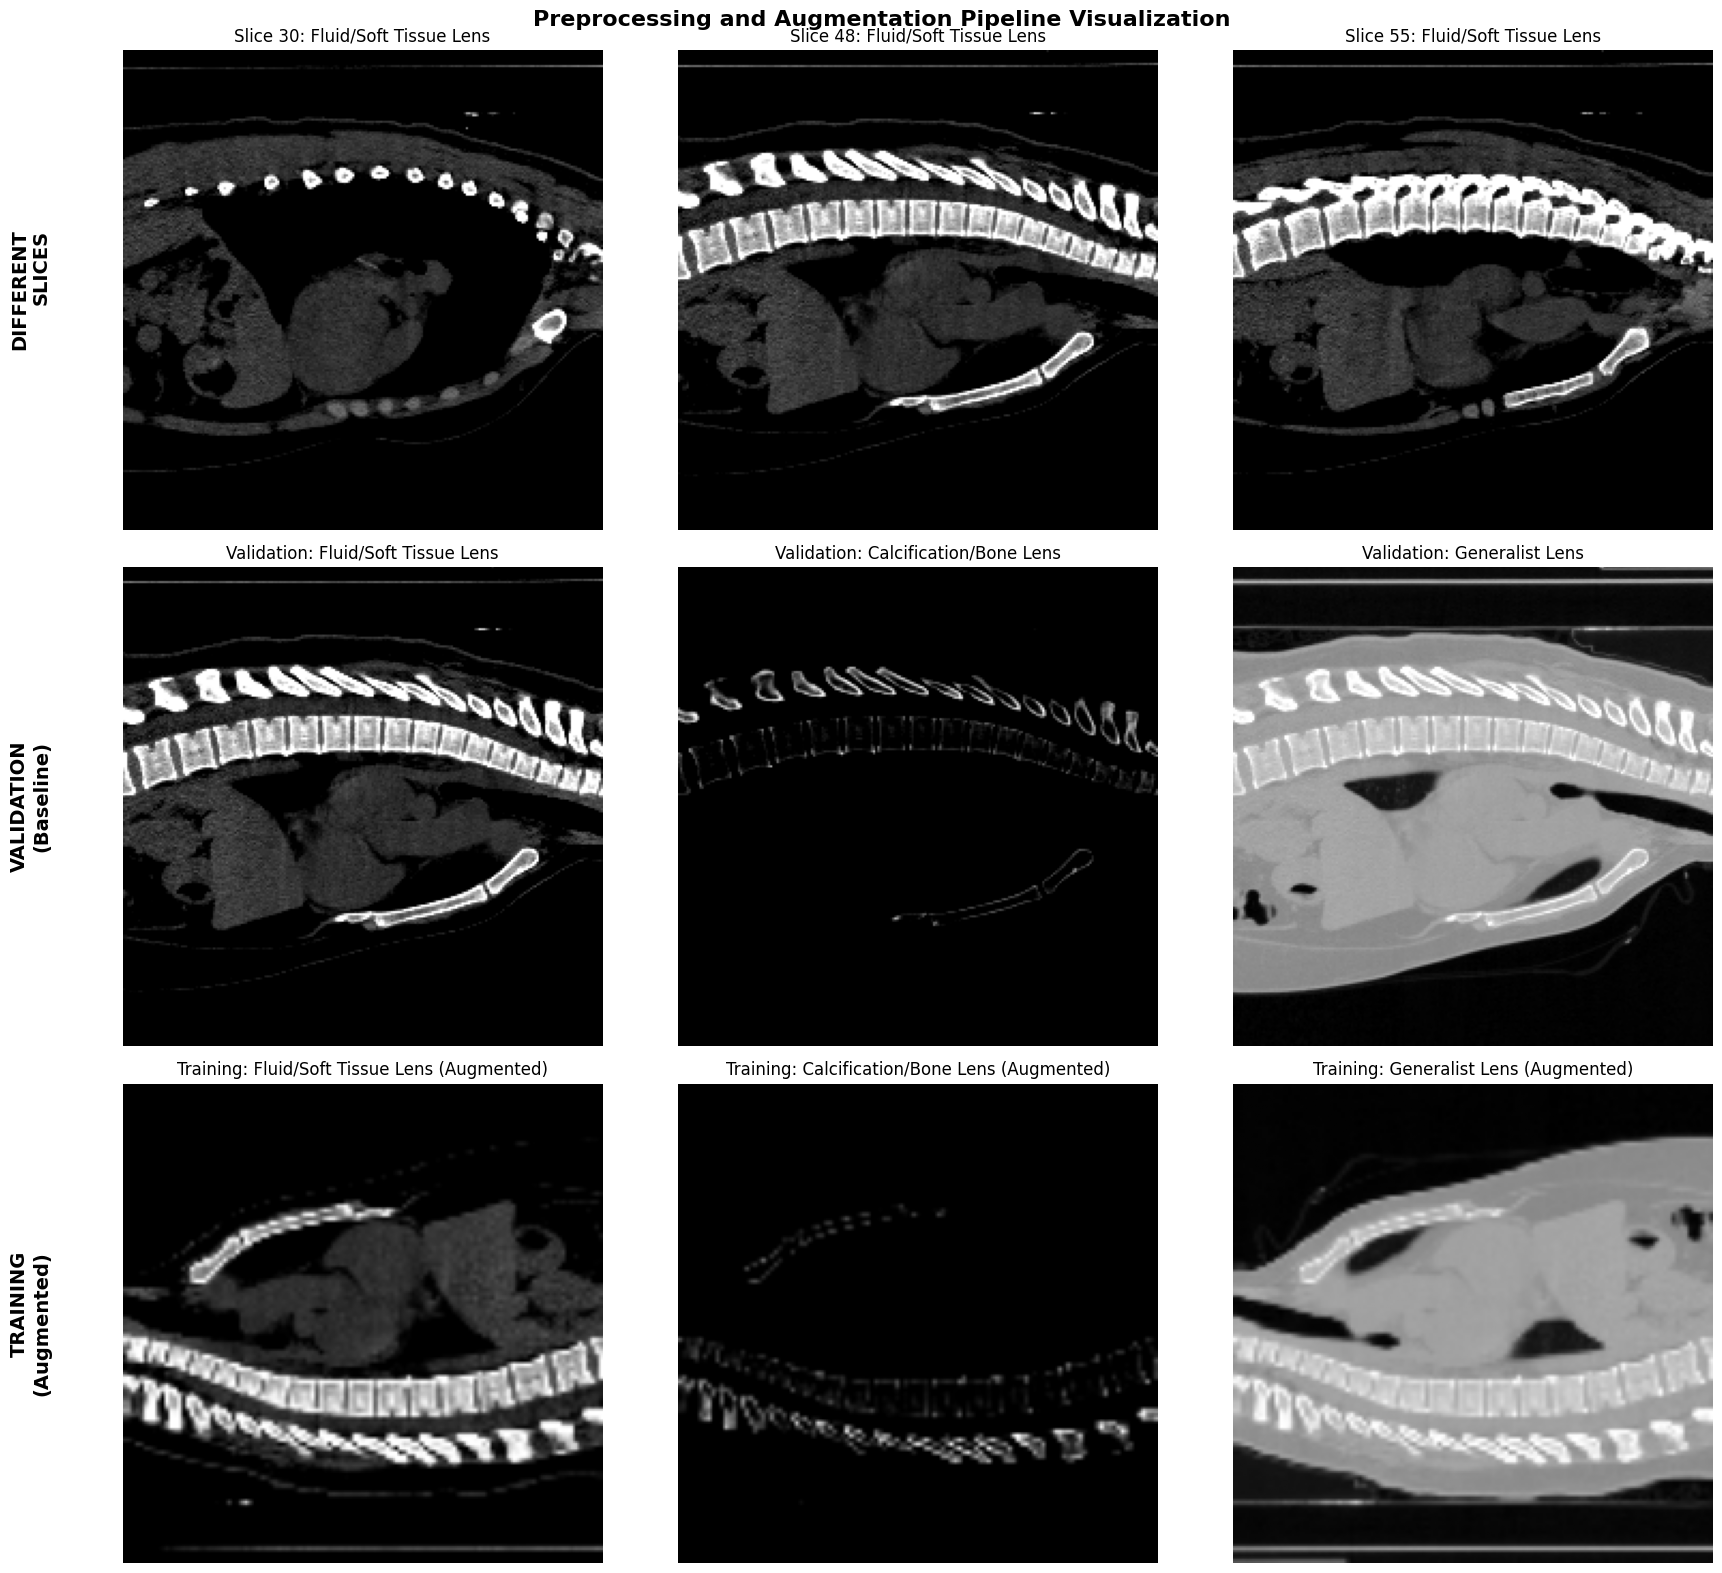


Visualization Notes:
• Row 1: Three consecutive slices (30, 48, 55) showing depth progression
         Uses Fluid/Soft Tissue Lens (Channel 0) to show anatomical continuity
• Row 2: All 3 windowing channels at mid-slice (baseline preprocessing)
• Row 3: Same as Row 2 but with augmentation applied (training pipeline)
• Augmentations include: flips, rotations, noise, blur, intensity changes


In [3]:
import matplotlib.pyplot as plt
from modules.transforms import get_train_transforms, get_valid_transforms

print("Creating Transform Pipelines")

# Create training transforms (preprocessing + augmentation)
train_transforms = get_train_transforms(spatial_size=(96, 224, 224))

# Create validation transforms (preprocessing only, no augmentation)
valid_transforms = get_valid_transforms(spatial_size=(96, 224, 224))

print("\nTraining transforms: Preprocessing + Augmentation")
print("Validation transforms: Preprocessing only (no augmentation)")

# Test both pipelines on the same patient
test_patient = train_records[0]
print(f"\nProcessing patient: {test_patient['image']}")

# Apply validation transforms (baseline preprocessing)
print("\nApplying validation transforms (preprocessing only)...")
valid_data = valid_transforms(test_patient)
valid_tensor = valid_data["image"]

# Apply training transforms (preprocessing + augmentation)
print("Applying training transforms (preprocessing + augmentation)...")
train_data = train_transforms(test_patient)
train_tensor = train_data["image"]

print("Transform Output Shapes")
print(f"Validation output: {valid_tensor.shape} [channels, depth, height, width]")
print(f"Training output:   {train_tensor.shape} [channels, depth, height, width]")

# Calculate slice indices for visualization
total_depth = valid_tensor.shape[1]
z_mid = total_depth // 2
z_prev =  30#max(0, z_mid - 1)  
z_next =  55#min(total_depth - 1, z_mid + 1) 

print(f"\nVisualization slices: {z_prev}, {z_mid}, {z_next} (out of {total_depth} total slices)")

# Visualization - 3 rows: consecutive slices, validation, training
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle(f'Preprocessing and Augmentation Pipeline Visualization', fontsize=16, fontweight='bold')

# Row 1: Three Consecutive Slices (Fluid/Soft Tissue Lens only)
axes[0, 0].imshow(valid_tensor[0, z_prev, :, :], cmap="gray")
axes[0, 0].set_title(f"Slice {z_prev}: Fluid/Soft Tissue Lens", fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(valid_tensor[0, z_mid, :, :], cmap="gray")
axes[0, 1].set_title(f"Slice {z_mid}: Fluid/Soft Tissue Lens", fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(valid_tensor[0, z_next, :, :], cmap="gray")
axes[0, 2].set_title(f"Slice {z_next}: Fluid/Soft Tissue Lens", fontsize=12)
axes[0, 2].axis('off')

# Row 2: Validation (Preprocessing Only) - All 3 Channels at mid-slice
axes[1, 0].imshow(valid_tensor[0, z_mid, :, :], cmap="gray")
axes[1, 0].set_title("Validation: Fluid/Soft Tissue Lens", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(valid_tensor[1, z_mid, :, :], cmap="gray")
axes[1, 1].set_title("Validation: Calcification/Bone Lens", fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(valid_tensor[2, z_mid, :, :], cmap="gray")
axes[1, 2].set_title("Validation: Generalist Lens", fontsize=12)
axes[1, 2].axis('off')

# Row 3: Training (Preprocessing + Augmentation) - All 3 Channels at mid-slice
axes[2, 0].imshow(train_tensor[0, z_mid, :, :], cmap="gray")
axes[2, 0].set_title("Training: Fluid/Soft Tissue Lens (Augmented)", fontsize=12)
axes[2, 0].axis('off')

axes[2, 1].imshow(train_tensor[1, z_mid, :, :], cmap="gray")
axes[2, 1].set_title("Training: Calcification/Bone Lens (Augmented)", fontsize=12)
axes[2, 1].axis('off')

axes[2, 2].imshow(train_tensor[2, z_mid, :, :], cmap="gray")
axes[2, 2].set_title("Training: Generalist Lens (Augmented)", fontsize=12)
axes[2, 2].axis('off')

# Add row labels
axes[0, 0].text(-0.15, 0.5, 'DIFFERENT\nSLICES', 
                transform=axes[0, 0].transAxes, fontsize=14, fontweight='bold',
                va='center', ha='right', rotation=90)
axes[1, 0].text(-0.15, 0.5, 'VALIDATION\n(Baseline)', 
                transform=axes[1, 0].transAxes, fontsize=14, fontweight='bold',
                va='center', ha='right', rotation=90)
axes[2, 0].text(-0.15, 0.5, 'TRAINING\n(Augmented)', 
                transform=axes[2, 0].transAxes, fontsize=14, fontweight='bold',
                va='center', ha='right', rotation=90)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("Visualization Notes:")
print(f"{'='*80}")
print(f"• Row 1: Three consecutive slices ({z_prev}, {z_mid}, {z_next}) showing depth progression")
print("         Uses Fluid/Soft Tissue Lens (Channel 0) to show anatomical continuity")
print("• Row 2: All 3 windowing channels at mid-slice (baseline preprocessing)")
print("• Row 3: Same as Row 2 but with augmentation applied (training pipeline)")
print("• Augmentations include: flips, rotations, noise, blur, intensity changes")
print(f"{'='*80}")

## Create Datasets and DataLoaders

Now that we have verified our transform pipelines work correctly, we create MONAI Datasets and DataLoaders to prepare for training:

- **Dataset**: Wraps our patient records with transform pipelines
- **DataLoader**: Handles batching, shuffling, and data loading

With 3 training patients and batch_size=2, we'll have 2 batches per epoch:
- Batch 1: 2 patients
- Batch 2: 1 patient

The validation set has only 1 patient, so batch_size=1.

In [4]:
from monai.data import Dataset, DataLoader
import torch

print("Creating Datasets and DataLoaders")

# Create MONAI Datasets
# Dataset applies transforms to each record when accessed
train_ds = Dataset(data=train_records, transform=train_transforms)
val_ds = Dataset(data=val_records, transform=valid_transforms)

print(f"\nDataset sizes:")
print(f"  Training dataset: {len(train_ds)} patients")
print(f"  Validation dataset: {len(val_ds)} patients")

# Create DataLoaders
# DataLoader batches multiple samples together and handles shuffling
batch_size = 2

train_loader = DataLoader(
    train_ds, 
    batch_size=batch_size, 
    shuffle=True,                          
    num_workers=0,                          
    pin_memory=torch.cuda.is_available()   
)

val_loader = DataLoader(
    val_ds, 
    batch_size=1,                          
    shuffle=False,                         
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"\nDataLoader configuration:")
print(f"  Training batch size: {batch_size}")
print(f"  Validation batch size: 1")
print(f"  Training batches per epoch: {len(train_loader)}")
print(f"  Validation batches per epoch: {len(val_loader)}")

# Test loading a batch from training loader
print("Testing DataLoader - Loading one training batch")

batch = next(iter(train_loader))
x = batch["image"]
y = batch["label"]

print(f"\nBatch contents:")
print(f"  Image tensor shape: {x.shape}")
print(f"    - Batch dimension: {x.shape[0]} (number of patients in batch)")
print(f"    - Channel dimension: {x.shape[1]} (3 windowing channels)")
print(f"    - Depth dimension: {x.shape[2]} (number of CT slices)")
print(f"    - Height dimension: {x.shape[3]} (224 pixels)")
print(f"    - Width dimension: {x.shape[4]} (224 pixels)")
print(f"  Label tensor shape: {y.shape}")
print(f"    - Batch dimension: {y.shape[0]} (number of patients)")
print(f"    - Label dimension: {y.shape[1]} (18 abnormality classes)")

print(f"\nTensor data types:")
print(f"  Image dtype: {x.dtype}")
print(f"  Label dtype: {y.dtype}")

print(f"\nImage value range:")
print(f"  Min: {x.min().item():.4f}")
print(f"  Max: {x.max().item():.4f}")
print(f"  Mean: {x.mean().item():.4f}")

print(f"\nLabel values for this batch:")
for i in range(y.shape[0]):
    num_positive = y[i].sum().item()
    print(f"  Patient {i+1}: {int(num_positive)} positive abnormalities out of 18")
    positive_indices = torch.where(y[i] == 1)[0].tolist()
    print(f"    Positive class indices: {positive_indices}")

Creating Datasets and DataLoaders

Dataset sizes:
  Training dataset: 3 patients
  Validation dataset: 1 patients

DataLoader configuration:
  Training batch size: 2
  Validation batch size: 1
  Training batches per epoch: 2
  Validation batches per epoch: 1
Testing DataLoader - Loading one training batch

Batch contents:
  Image tensor shape: torch.Size([2, 3, 96, 224, 224])
    - Batch dimension: 2 (number of patients in batch)
    - Channel dimension: 3 (3 windowing channels)
    - Depth dimension: 96 (number of CT slices)
    - Height dimension: 224 (224 pixels)
    - Width dimension: 224 (224 pixels)
  Label tensor shape: torch.Size([2, 18])
    - Batch dimension: 2 (number of patients)
    - Label dimension: 18 (18 abnormality classes)

Tensor data types:
  Image dtype: torch.float32
  Label dtype: torch.float32

Image value range:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.1369

Label values for this batch:
  Patient 1: 1 positive abnormalities out of 18
    Positive class indices: [

## Model Instantiation and Architecture

Instantiate the `MultiAbnormalityClassifier` model with our refactored architecture:

### Architecture Overview:
1. **Frozen DinoV3 Encoder** (loaded from local pretrained model)
   - Processes each 2D slice independently
   - Extracts 384-dimensional embeddings per slice
   - Parameters are frozen (not trained)

2. **Mean Pooling Aggregation**
   - Aggregates slice embeddings across depth dimension
   - Produces single 384-dim patient-level embedding

3. **Trainable Classification Head**
   - 3-layer MLP: 384 → 512 → 256 → 18
   - Predicts 18 abnormality classes
   - Only these parameters are trained

This approach allows us to leverage powerful pretrained vision features while training efficiently on limited medical imaging data.

In [5]:
from modules.multiabnormality_classification_model import MultiAbnormalityClassifier
import torch

print("Model Instantiation")

# Define path to local DinoV3 model
LOCAL_DINOV2_DIR = "pretrained_encoders/dinov2-small"

print(f"\nLoading model with local DinoV2 from: {LOCAL_DINOV2_DIR}")

# Instantiate the model
model = MultiAbnormalityClassifier(
    encoder_type='dinov2',
    local_model_dir=LOCAL_DINOV2_DIR,
    num_classes=18,
    dropout=0.3,
    learning_rate=1e-3
)

# Check device availability and move model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"\nModel loaded successfully")
print(f"Device: {device}")

# Display model architecture
print("Model Architecture")

print(f"\n1. Encoder (Frozen DinoV2):")
print(f"   - Type: {model.encoder.__class__.__name__}")
print(f"   - Embedding dimension: {model.encoder.embedding_dim}")
print(f"   - Status: Frozen (not trained)")

print(f"\n2. Classification Head (Trainable):")
print(f"   - Architecture: {model.encoder.embedding_dim} → 512 → 256 → {model.hparams.num_classes}")
print(f"   - Dropout: {model.hparams.dropout}")
print(f"   - Output: {model.hparams.num_classes} abnormality classes")

# Count parameters
print("Parameter Counts")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} (classification head)")
print(f"Frozen parameters:    {frozen_params:,} (DinoV2 encoder)")
print(f"Trainable ratio:      {100 * trainable_params / total_params:.2f}%")

# Show optimizer configuration
print("\nTraining Configuration")

print(f"\nLearning rate: {model.hparams.learning_rate}")
print(f"Loss function: BCEWithLogitsLoss (multi-label classification)")
print(f"Optimizer: Adam (only on classification head parameters)")

# Test forward pass with a dummy batch
print("\nTesting Forward Pass")

print("\nRunning forward pass with sample batch...")
with torch.no_grad():
    # Get a batch from train_loader
    test_batch = next(iter(train_loader))
    test_images = test_batch["image"].to(device)
    test_labels = test_batch["label"].to(device)
    
    # Forward pass
    logits = model(test_images)
    probs = torch.sigmoid(logits)
    
    print(f"\nInput shape:  {test_images.shape} [batch, channels, depth, height, width]")
    print(f"Output shape: {logits.shape} [batch, num_classes]")
    print(f"\nOutput logits range: [{logits.min().item():.3f}, {logits.max().item():.3f}]")
    print(f"Output probs range:  [{probs.min().item():.3f}, {probs.max().item():.3f}]")

Model Instantiation

Loading model with local DinoV2 from: pretrained_encoders/dinov2-small
Loading DinoV2 encoder from local directory: pretrained_encoders/dinov2-small...
DinoV2 encoder loaded and frozen (384-dim embeddings)

Model loaded successfully
Device: cpu
Model Architecture

1. Encoder (Frozen DinoV2):
   - Type: DinoV2Encoder
   - Embedding dimension: 384
   - Status: Frozen (not trained)

2. Classification Head (Trainable):
   - Architecture: 384 → 512 → 256 → 18
   - Dropout: 0.3
   - Output: 18 abnormality classes
Parameter Counts

Total parameters:     22,391,186
Trainable parameters: 334,610 (classification head)
Frozen parameters:    22,056,576 (DinoV2 encoder)
Trainable ratio:      1.49%

Training Configuration

Learning rate: 0.001
Loss function: BCEWithLogitsLoss (multi-label classification)
Optimizer: Adam (only on classification head parameters)

Testing Forward Pass

Running forward pass with sample batch...

Input shape:  torch.Size([2, 3, 96, 224, 224]) [batch,

## Training Loop with PyTorch Lightning

Now we train the model using PyTorch Lightning's `Trainer`. With only 3 training patients, this is a demonstration of the training mechanics rather than actual model learning.

### What to expect:
- **2 epochs** with 2 batches per epoch (batch 1: 2 patients, batch 2: 1 patient)
- **Training metrics**: Loss, AUC, F1, accuracy
- **Validation metrics**: Same metrics on 1 validation patient
- **Note**: Metrics won't be meaningful with so few samples, but the pipeline will be validated

The model trains only the classification head (frozen encoder), so training is fast even on CPU.

In [6]:
from pytorch_lightning import Trainer

print("Training with PyTorch Lightning")

# Create PyTorch Lightning Trainer
trainer = Trainer(
    max_epochs=2,                      # Run 2 epochs for demonstration
    accelerator='auto',                # Use GPU if available, else CPU
    devices=1,                         # Single device
    log_every_n_steps=1,              # Log every batch (we have very few)
    enable_checkpointing=False,        # Don't save checkpoints for demo
    enable_progress_bar=True,          # Show progress bar
    enable_model_summary=True          # Show model summary before training
)

print(f"\nTrainer configuration:")
print(f"  Max epochs: {trainer.max_epochs}")
print(f"  Accelerator: {trainer.accelerator}")
print(f"  Log every N steps: {trainer.log_every_n_steps}")

# Train the model
trainer.fit(model, train_loader, val_loader)

# Display final metrics
print("\nFinal Training Metrics:")
if trainer.callback_metrics:
    for key, value in trainer.callback_metrics.items():
        if 'train' in key:
            print(f"  {key}: {value:.4f}")

print("\nFinal Validation Metrics:")
if trainer.callback_metrics:
    for key, value in trainer.callback_metrics.items():
        if 'val' in key:
            print(f"  {key}: {value:.4f}")

print("\n" + "=" * 80)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training with PyTorch Lightning

Trainer configuration:
  Max epochs: 2
  Accelerator: <pytorch_lightning.accelerators.cpu.CPUAccelerator object at 0x13cb91460>
  Log every N steps: 1


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ DinoV2Encoder      │ 22.1 M │ train │     0 │
│ 1 │ head      │ ClassificationHead │  334 K │ train │     0 │
│ 2 │ criterion │ BCEWithLogitsLoss  │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 334 K                                                                                            
Non-trainable params: 22.1 M                                                                                       
Total params: 22.4 M                                                                                               
Total estimated model params size (MB): 89                                                                         
Modules in train mode: 13                                                                                          
Modules in eval mode: 236                                                                                          
Total FLOPs: 0

Output()

/Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/venv/lib/python3.12/site-packa
ges/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers 
which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the 
`DataLoader` to improve performance.

/Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/venv/lib/python3.12/site-packa
ges/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers 
which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the 
`DataLoader` to improve performance.

/Users/ant-smalls/Desktop/UCD-Spring/RDGY41850-Data_Challenges/local_vlm3d_challenge/venv/lib/python3.12/site-packa
ges/pytorch_lightning/loops/fit_loop.py:534: Found 236 module(s) in eval mode at the start of training. This may 
lead to unexpected behavior during training. If this is intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=2` reached.



Final Training Metrics:
  train_loss: 0.5748
  train_loss_step: 0.5536
  train_loss_epoch: 0.5748

Final Validation Metrics:
  val_loss: 0.5957
  val_auc: 0.0000
  val_accuracy: 0.6667
  val_f1: 0.2500
  val_precision: 0.3333
  val_mean_ap: 0.0000
  val_recall: 0.2000
  val_hamming_loss: 0.3333



## Inference on Validation Case

Demonstrate inference on a single validation patient to show:
1. How to run the model in evaluation mode
2. Converting logits to probabilities
3. Comparing predictions to ground truth labels
4. Displaying top predicted abnormalities

This shows the complete prediction pipeline that would be used on the server for the full test set.

### The 18 Abnormality Classes:
The model predicts probabilities for each of these conditions:
1. Medical material
2. Arterial wall calcification
3. Cardiomegaly
4. Pericardial effusion
5. Coronary artery wall calcification
6. Hiatal hernia
7. Lymphadenopathy
8. Emphysema
9. Atelectasis
10. Lung nodule
11. Lung opacity
12. Pulmonary fibrotic sequela
13. Pleural effusion
14. Mosaic attenuation pattern
15. Peribronchial thickening
16. Consolidation
17. Bronchiectasis
18. Interlobular septal thickening

In [7]:
import numpy as np

# Define the 18 abnormality class labels
LABELS_18 = [
    "Medical material",
    "Arterial wall calcification",
    "Cardiomegaly",
    "Pericardial effusion",
    "Coronary artery wall calcification",
    "Hiatal hernia",
    "Lymphadenopathy",
    "Emphysema",
    "Atelectasis",
    "Lung nodule",
    "Lung opacity",
    "Pulmonary fibrotic sequela",
    "Pleural effusion",
    "Mosaic attenuation pattern",
    "Peribronchial thickening",
    "Consolidation",
    "Bronchiectasis",
    "Interlobular septal thickening"
]

print("Inference on Validation Patient")

# Set model to evaluation mode
model.eval()

# Get validation batch (only 1 patient)
val_batch = next(iter(val_loader))
x = val_batch["image"].to(device)
y_true = val_batch["label"]

# Convert y_true to tensor if it's a list
if isinstance(y_true, list):
    y_true = torch.tensor(y_true, dtype=torch.float32)

y_true = y_true[0].cpu().numpy()  # Get first (and only) patient's labels

print(f"\nInput shape: {x.shape}")
print(f"Ground truth labels: {y_true.shape}")

# Run inference
print("\nRunning inference...")
with torch.no_grad():
    logits = model(x)
    probs = torch.sigmoid(logits)[0].cpu().numpy()

print(f"Output logits range: [{logits.min().item():.3f}, {logits.max().item():.3f}]")
print(f"Output probabilities range: [{probs.min():.3f}, {probs.max():.3f}]")

# Display results
print("Top 10 Predicted Abnormalities")

topk_indices = np.argsort(-probs)[:10]  # Top 10 predictions

print(f"\n{'Rank':<6} {'Label':<42} {'Probability':<12} {'Predicted':<10} {'Ground Truth':<12}")

for rank, idx in enumerate(topk_indices, 1):
    label_name = LABELS_18[idx]
    prob = probs[idx]
    pred = int(prob > 0.5)
    gt = int(y_true[idx])
    
    # Add indicator if prediction matches ground truth
    match = "✓" if pred == gt else "✗"
    
    print(f"{rank:<6} {label_name:<42} {prob:.3f}        {pred:<10} {gt:<12} {match}")

# Show all ground truth positive labels
print("All Ground Truth Positive Abnormalities")

positive_indices = np.where(y_true == 1)[0]

if len(positive_indices) > 0:
    print(f"\nThis patient has {len(positive_indices)} positive abnormalities:\n")
    print(f"{'Label':<42} {'Probability':<12} {'Predicted':<10} {'Status':<10}")
    print("-" * 80)
    
    for idx in positive_indices:
        label_name = LABELS_18[idx]
        prob = probs[idx]
        pred = int(prob > 0.5)
        status = "Detected ✓" if pred == 1 else "Missed ✗"
        
        print(f"{label_name:<42} {prob:.3f}        {pred:<10} {status:<10}")
else:
    print("\nThis patient has no positive abnormalities (all healthy).")

# Summary statistics
print("Prediction Summary")

num_gt_positive = int(y_true.sum())
num_pred_positive = int((probs > 0.5).sum())
num_correct = int(((probs > 0.5) == y_true).sum())

print(f"\nGround truth positives:  {num_gt_positive} / 18")
print(f"Predicted positives:     {num_pred_positive} / 18")
print(f"Correct predictions:     {num_correct} / 18")
print(f"Accuracy:                {100 * num_correct / 18:.1f}%")

Inference on Validation Patient

Input shape: torch.Size([1, 3, 96, 224, 224])
Ground truth labels: (18,)

Running inference...
Output logits range: [-1.310, 1.499]
Output probabilities range: [0.213, 0.817]
Top 10 Predicted Abnormalities

Rank   Label                                      Probability  Predicted  Ground Truth
1      Lung nodule                                0.817        1          0            ✗
2      Lymphadenopathy                            0.552        1          0            ✗
3      Arterial wall calcification                0.508        1          1            ✓
4      Lung opacity                               0.496        0          1            ✗
5      Coronary artery wall calcification         0.408        0          0            ✓
6      Peribronchial thickening                   0.381        0          1            ✗
7      Pulmonary fibrotic sequela                 0.343        0          0            ✓
8      Consolidation                              